In [7]:
import os
from dotenv import load_dotenv
from typing import Annotated, TypedDict
load_dotenv()

True

In [68]:
from langgraph.graph import StateGraph,  START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages

In [8]:
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key

In [70]:
# Define state
class State(TypedDict):
    messages: Annotated[list[dict], add_messages]

In [71]:
# Setup LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7,
)

In [72]:
# Define the chatbot node
def chatbot(state:State):
  return {"messages":[llm.invoke(state["messages"])]}

In [73]:
# Create the state graph
graph=StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

graph_compile=graph.compile()

In [75]:
result=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [76]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Hello! I am Gemini, a large language model created by Google. \n\nHow can I help you today?', 'extras': {'signature': 'Eq8GCqwGARFNMg8Ft7SMm9RHKQrDu01BI9NA+VhFOsEpD5Zg62KulORWgn9S7YcIZ2oQVUUOiubKAGviBhybUXMuNij1AGS9SMk46d83oX+cGTAnAdr91GE/Qtfvc5VgWpeZQYd1bFjDbbzRZ2wj5IC2v+ZP4bZCQ3+Ty+jCRNQhNZxy+G+cDeJ53EHwsXcTblMHCUIBGCvhZx1CBPoy4smwLMibnc3Ta4M2hjIH/LUkdUIYY7CuEwEhGKXM9Bx+xQ2xLC9SiFoiL3E6+K6s7YrmCx/aMpgW41EaptGAkaLntxYFI7m9ORZR3ggf68fUtU6GeysG5JcqgEkF+BrkoNHaofFW4GZcOzBDuENHt83XEOcjNdmeKDaA8e9bMSrnU+R8sLqVQgZKmAcJ6Of2kdW7H8bh7XC/HST3adHsCjbIWBXZNKQ0NL5yfjEDTncXFOOQP5oB+XXWl8vJ/TpQmJ93Nq5XWL9du0zmHHj8aTWZ1pHhWb3uw3I0Ril7cNhdUdGi3EQq0eF/zkAiK8gakuTHaEl6DIf9dVYHmPxYHQ4n9OB2MlkBhxTSxO5VAZ/oB+sjFV1NdCKeIfjUZeo7C85fFGdmh84CeV1qhJvBYo4SRyLd9NrDHHvVO7q4us9LvrBpiurCDfIjqZ+JzSenViuCxUFv5wjjQvh5zWsg8EefDl0BDQZkiYduQ1/RL3QsvtIqMVdzD7+3EC1iWshWJFqQ/lSlYAVyEeCsTENW8UyVVw1pdOjBaoAcknto9FFjGyXoeZQa7Imff7AYAZKbMWvdF+aWhGaSkn/i42yIJxui3voy9krWZDU3/nyM8aR9jD3PRVeyLSjiG9/YeLNFqk

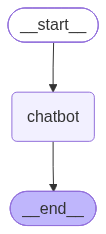

In [77]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())

In [ ]:
# add another node in the above workflow - summary the conversation

def summarize(state:State):
    summary_prompt = {"role": "user", "content": "Please provide a short summary of our conversation above."}
    
    summary = llm.invoke(state["messages"] + [summary_prompt])
    return {"messages": [summary]}

In [84]:
graph = StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize", summarize)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", "summarize")
graph.add_edge("summarize", END)

graph_compile = graph.compile()

In [85]:
res=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [89]:
print(res["messages"][-1].content)
# This can be example of prompt chaining workflow where the output of one node is used as input to another node. In this case, the chatbot node generates a response based on the user's input, and then the summarize node generates a summary of the conversation.

[{'type': 'text', 'text': 'Here is a short summary of our conversation so far:\n\nYou asked who I am, and I introduced myself as Gemini, an AI created by Google, and offered my assistance.', 'extras': {'signature': 'EpsJCpgJARFNMg9d5diH32OlKJWL/r+TNApzxykSgQDVrvQ7XV7oeYBNuG+hon79tqKG051D4dV2I3la0vRrZ138h7KVapY6CikLfMimFacVCu406SpJBeZl77SJFqdV18/cLIHR+yjY7kTj/mLNPEu8R2s3nncuCm0v531PBg0sBQjv4A7/nDe9ZiWqWSuXT38GdGokJx/VRCNM8Cwfuy979AZ+IgsUbACa5ls/FXgwptsuu77inuCdTl85OSkSRm3fn6OkjhzDO2pRbZUeG5hwldH+FostODP4vTK1rRxcT2CpByloqa4ZQ9bMcjo8G1+J1Q5eZiy9Iyr/o5wF0TlPMlgnC1Cz63eR1anfxc9MtGmItpmmnNwodIzXJSCXDVmcfJHTO21LnoOXdChCOR0CF6+Ry8wIrw+j4yOnetooZNy7qca0Zy/DUgq14g+KPIc5abrYt0itgvehunQ8ZAFFF4j/EHGx4K4lCCOifXpzb4FEw6jqQi78SNmHsZVhXre1q4UlznO2BYhDT7jmfkJE7QdmCMLhsUi+2NiY6HxvghqwC4P5H6XFZsYNHNzCN8KKPHdiW8546HdyJMN9Is7RKgNQ7IsvaTLahWBXmGJRl4xU/4Xi9LoXIyxF4EMwqEUcerOAbGO4QmYCAHhaJoAdSJh6dNBemJIkfDCB4CRbRt+DUE887OozNj6o/KrLytg0dS2FC28dMiLmcKSuE2coEmYmHk+gwl3jziUULSJRiM0+efHSbeBf4+g72dAkRR8lF+2l6Ql0our8

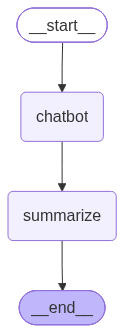

In [87]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())

### DAY-2(LangGraph)  Implement Parallel Workflows in LangGraph

In [17]:

# Parallel Workflow in LangGraph — Product Review Analyzer

import asyncio
import time
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",   # verify this model name is current for your account/region
    temperature=0.7,
)


In [18]:
# 1. STATE SCHEMA
class ReviewState(TypedDict):
    review_text: str
    findings: Annotated[list, operator.add]   # <-- reducer, merges parallel writes
    final_report: str

In [14]:
# 2. THE THREE PARALLEL WORKERS — each makes its own real LLM call

async def analyze_sentiment(state: ReviewState) -> dict:
    print(f"  [sentiment]  START  t={time.perf_counter():.2f}")
    prompt = f"In one short line, classify the sentiment (Positive/Negative/Mixed) of this review:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [sentiment]  END    t={time.perf_counter():.2f}")
    return {"findings": [f"Sentiment: {resp.content}"]}


async def extract_keywords(state: ReviewState) -> dict:
    print(f"  [keywords]   START  t={time.perf_counter():.2f}")
    prompt = f"List the 3-5 most important keywords/topics in this review, comma separated:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [keywords]   END    t={time.perf_counter():.2f}")
    return {"findings": [f"Keywords: {resp.content}"]}


async def summarize(state: ReviewState) -> dict:
    print(f"  [summary]    START  t={time.perf_counter():.2f}")
    prompt = f"Summarize this review in one sentence:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [summary]    END    t={time.perf_counter():.2f}")
    return {"findings": [f"Summary: {resp.content}"]}



# 3. THE JOIN / AGGREGATOR NODE (fan-in)
async def build_report(state: ReviewState) -> dict:
    print(f"  [aggregator] START  t={time.perf_counter():.2f} (all 3 branches done)")
    report = "FINAL REPORT\n" + "\n".join(f"  - {f}" for f in state["findings"])
    return {"final_report": report}


In [13]:
# 4. BUILD THE GRAPH 
graph = StateGraph(ReviewState)

graph.add_node("sentiment", analyze_sentiment)
graph.add_node("keywords", extract_keywords)
graph.add_node("summary", summarize)
graph.add_node("aggregator", build_report)

# Fan-out: START branches into all three at once
graph.add_edge(START, "sentiment")
graph.add_edge(START, "keywords")
graph.add_edge(START, "summary")

# Fan-in: all three converge on aggregator
graph.add_edge("sentiment", "aggregator")
graph.add_edge("keywords", "aggregator")
graph.add_edge("summary", "aggregator")

graph.add_edge("aggregator", END)

app = graph.compile()

In [12]:
# 5. RUN IT
async def main():
    review = "The battery lasts forever and delivery was fast, packaging was a bit crushed though."

    print("Running graph...\n")
    t0 = time.perf_counter()

    result = await app.ainvoke({"review_text": review, "findings": []})

    t1 = time.perf_counter()
    print(f"\nTotal wall-clock time: {t1 - t0:.2f}s (all 3 LLM calls ran concurrently)\n")
    print(result["final_report"])

In [10]:
await main()

Running graph...

  [keywords]   START  t=898684.50
  [sentiment]  START  t=898684.51
  [summary]    START  t=898684.51


d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


  [sentiment]  END    t=898687.39
  [keywords]   END    t=898765.61
  [summary]    END    t=898795.38
  [aggregator] START  t=898795.39 (all 3 branches done)

Total wall-clock time: 110.89s (all 3 LLM calls ran concurrently)

FINAL REPORT
  - Keywords: [{'type': 'text', 'text': 'Battery life, Delivery speed, Packaging', 'extras': {'signature': 'EvYKCvMKARFNMg82p6aa9weVrHfleFJc7uz9Cj7d4cIdxKHFwxRLx/C3yW2f4zqWbLM6QB06bapTjdxD+4G8wJ9MJZso03glbaUdcw8v3LXUPlXuy9yW2yxsKE5tk3ZH64iZOW0uu2jfPZ4/b2Ef5xO/Fi6CQuTJH8mW+XDfqSeATv4dj0fZKKyqJKu8e8VtCGtndRtM5KlvdklLvf5xqAhg77rcmQ1IKtcCNeD+hwXDDzXK8Jh7E8FLS6OiT/TZGQdtrbjY97xiNc/Pqx0v3CQD/+6LjtYAtG4J6XAx/LVx7qk4WWVVOZdVzL8ueu00vGlvBk+KVwGh7rEQbN7dssJyvhb39ikGxdGVeoGHk/Pl/SpxuPsC/qHdbFbx2TsoaWcbZDfZQAIza5zaY0P2EkFMfqkn3JCXAF4CbMwkQmbHb0OUcs5QIUKiqSlE3IXHYZVx7n0ZJbelXPJRRbv946k5hFb9ds1m1BJhyKG3eBXd8WFPEmUFW4U+5aBwzlX35WyBkN6++rpm0BqaYvADEWN0CCqMxmWEzFkO8G5TJ5UHStamK+zKv0TuwpbT1LVjSi/veeclMUHIB59tvzI0HMe/NtGGdQ1XYRVs5nVgKvZSxOf4Gm0xRfg5WhBai77SlZPZxfeGXHiUE

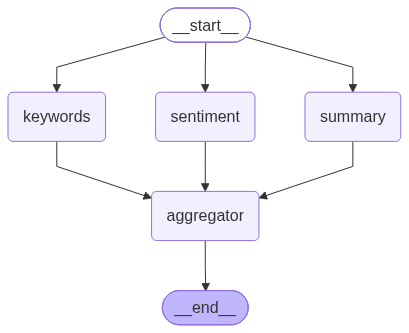

In [11]:
app


1. **Fan-out = multiple edges from one node.** If two nodes both receive an edge from the same source and don't depend on each other, LangGraph runs them at the same time. You don't call `asyncio.gather` yourself — you just draw the graph that way.

2. **Fan-in = multiple edges into one node.** That node automatically waits for every incoming branch to finish. Free synchronization, no manual join logic.

3. **Shared state written by multiple parallel branches needs a reducer.** This is the one rule that actually breaks things if you forget it. The moment two nodes write to the *same key* in the *same step*, you must tell LangGraph how to merge those writes (`operator.add`, or a custom function) — otherwise it throws a conflict error. Different keys per branch = no reducer needed. Same key = reducer required.
